IMPORTS

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense
)

CARGAR DATASET

In [2]:
df = pd.read_csv("CCH_dataset.csv")
df["datalectura"] = pd.to_datetime(df["datalectura"])

SELECCIONAR CT

In [3]:
ct_estudio = "CT-0710"

df = df[df["ct"] == ct_estudio].copy()

ORDENAR DATALECTURA

In [4]:
df = df.sort_values("datalectura")

SELECCIONAR VARIABLE A PREDECIR

In [5]:
data = df["ENERGIA_ENTRANTE"].values

ESCALAR DATOS

In [6]:
scaler = MinMaxScaler()

data_scaled = scaler.fit_transform(
    data.reshape(-1,1)
)

CREAR SECUENCIAS

In [7]:
def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(seq_length, len(data)):

        X.append(
            data[i-seq_length:i]
        )

        y.append(data[i])

    return np.array(X), np.array(y)

CREAR DATASET SECUENCIAL

In [8]:
SEQ_LENGTH = 24

X, y = create_sequences(
    data_scaled,
    SEQ_LENGTH
)

SPLIT TEMPORAL

In [9]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

CONSTRUIR LSTM (Long Short-Term Memory)

In [11]:
model = Sequential()

model.add(
    LSTM(
        64,
        input_shape=(SEQ_LENGTH,1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

ENTRENAR MODELO

In [12]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0169 - val_loss: 0.0098
Epoch 2/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0047 - val_loss: 0.0058
Epoch 3/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0037 - val_loss: 0.0050
Epoch 4/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0031 - val_loss: 0.0042
Epoch 5/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028 - val_loss: 0.0053
Epoch 6/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0028 - val_loss: 0.0044
Epoch 7/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0029 - val_loss: 0.0040
Epoch 8/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - val_loss: 0.0037
Epoch 9/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0025 - val_loss: 0.0041
Epoch 10/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0026 - val_loss: 0.0036
Epoch 11/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0025 - val_loss: 0.0037
Epoch 12/20
197/197 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step

PREDICCIÓN

In [13]:
y_pred_lstm = model.predict(X_test)

55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


DESNORMALIZAR

In [14]:
#PREDICCIONES
y_pred_lstm = scaler.inverse_transform(
    y_pred_lstm
)

#VALORES REALES
y_test_real = scaler.inverse_transform(
    y_test
)

MÉTRICAS

In [17]:
mae_lstm = mean_absolute_error(
    y_test_real,
    y_pred_lstm
)

rmse_lstm = np.sqrt(
    mean_squared_error(
        y_test_real,
        y_pred_lstm
    )
)

mape_lstm = np.mean(
    np.abs(
        (y_test_real.flatten() - y_pred_lstm.flatten())
        / y_test_real.flatten()
    )
) * 100

print("LSTM")

print("MAE:", mae_lstm)

print("RMSE:", rmse_lstm)

print("MAPE:", mape_lstm)

LSTM
MAE: 24.41813808271814
RMSE: 33.53193850094536
MAPE: 11.704460803955271


VISUALIZACIÓN

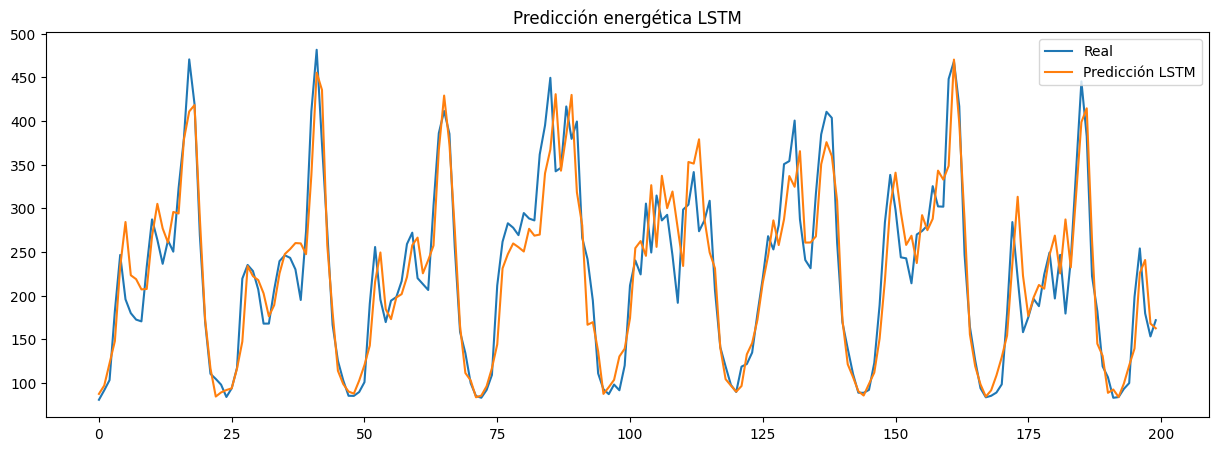

In [16]:
plt.figure(figsize=(15,5))

plt.plot(
    y_test_real[:200],
    label="Real"
)

plt.plot(
    y_pred_lstm[:200],
    label="Predicción LSTM"
)

plt.legend()

plt.title("Predicción energética LSTM")

plt.show()